# F2 – Preparación, transformación y validación de datos

## Generación Real CEN – TER CMPC Laja, Pacífico y Santa Fe

**Tema de investigación:**  
> **¿Qué patrones temporales de generación eléctrica caracterizan a las centrales TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe durante el período enero–agosto de 2026?**

Esta fase construye el conjunto analítico que permitirá responder la pregunta de investigación. La fuente original está en formato ancho y se transforma a una granularidad única **central–fecha–hora**.

La transformación no se plantea como una “limpieza” arbitraria, sino como una decisión estructural necesaria para analizar correctamente la dimensión temporal.

## 1. Objetivo técnico de F2

F2 debe:

- cargar reproduciblemente la fuente pública del CEN;
- verificar su estructura;
- delimitar exactamente las tres centrales del estudio;
- transformar las 24 columnas horarias a formato largo;
- construir las variables analíticas;
- validar integridad, granularidad y consistencia;
- caracterizar los registros de `0 MWh` sin atribuirles una causa no demostrada;
- generar evidencias exploratorias iniciales;
- exportar un dataset procesado reproducible.

El resultado esperado es **17.496 observaciones × 13 variables**.

## 2. Librerías y configuración

In [1]:
from pathlib import Path
import sys
import subprocess
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("=== VERIFICACIÓN DEL ENTORNO ===")
print("Python:", sys.version.split()[0])
print("Ejecutable:", sys.executable)
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

=== VERIFICACIÓN DEL ENTORNO ===
Python: 3.14.3
Ejecutable: c:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\.venv\Scripts\python.exe
pandas: 3.0.5
NumPy: 2.5.3
Matplotlib: 3.11.1


## 3. Rutas reproducibles

Se evita utilizar una ruta absoluta vinculada al computador de un integrante.

In [2]:
def encontrar_raiz_proyecto(inicio=None):
    """Localiza la raíz del repositorio usando archivos/carpetas esperados."""
    ruta = Path(inicio or Path.cwd()).resolve()

    for candidata in [ruta, *ruta.parents]:
        if (
            (candidata / "README.md").exists()
            and (candidata / "F1").exists()
            and (candidata / "F2").exists()
        ):
            return candidata

    raise FileNotFoundError(
        "No fue posible localizar la raíz del proyecto."
    )


RAIZ = encontrar_raiz_proyecto()

# Permitimos que Python encuentre los módulos de la carpeta src.
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))


# Funciones reutilizables del proyecto
from src.carga import cargar_datos_cen

from src.transformacion import (
    filtrar_periodo,
    filtrar_centrales,
    transformar_ancho_largo,
    crear_dia_semana,
    crear_id_observacion,
)

from src.validacion import (
    validar_sin_duplicados_exactos,
    validar_dataset_procesado,
)

from src.exportacion import exportar_dataset


RUTA_RAW = (
    RAIZ
    / "data"
    / "raw"
    / "generacion_real_cen_ene_ago_2026.csv"
)

RUTA_PROCESADO = (
    RAIZ
    / "data"
    / "processed"
    / "dataset_cen_centrales_cmpc_ene_ago_2026.csv"
)


print("Raíz:", RAIZ)
print("Entrada:", RUTA_RAW)
print("Salida:", RUTA_PROCESADO)

Raíz: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto
Entrada: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\raw\generacion_real_cen_ene_ago_2026.csv
Salida: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\processed\dataset_cen_centrales_cmpc_ene_ago_2026.csv


## 3.1. Estado de Git utilizado para la ejecución

Además de registrar el entorno de Python, se consulta el estado del repositorio y el commit actual. Esta información aporta trazabilidad a la ejecución. El estado puede mostrar archivos modificados durante el trabajo; se reporta como evidencia y no se fuerza artificialmente un repositorio limpio.

In [3]:
def ejecutar_git(*argumentos):
    """Ejecuta un comando Git desde la raíz del proyecto."""
    resultado = subprocess.run(
        ["git", *argumentos],
        cwd=RAIZ,
        capture_output=True,
        text=True,
        check=True
    )
    return resultado.stdout.strip()


print("=== ESTADO DE GIT ===")
print(ejecutar_git("status", "--short", "--branch"))
print("Commit:", ejecutar_git("rev-parse", "--short", "HEAD"))

=== ESTADO DE GIT ===
## mejora-retroalimentacion...origin/mejora-retroalimentacion
 M F1/F1_definicion.ipynb
 M F2/F2_preparacion_datos.ipynb
Commit: b1652a8


## 4. Carga de la fuente pública

In [4]:
# La lógica de carga se encuentra modularizada en src/carga.py
df_raw = cargar_datos_cen(RUTA_RAW)

print(
    f"Fuente cargada: {len(df_raw):,} filas × "
    f"{df_raw.shape[1]} columnas"
)

display(df_raw.head())

Fuente cargada: 359,891 filas × 33 columnas


,Año,Mes,Llave,Central,Coordinado,Grupo reporte,Tipo,Subtipo,Fecha,Hora 1,...,Hora 15,Hora 16,Hora 17,Hora 18,Hora 19,Hora 20,Hora 21,Hora 22,Hora 23,Hora 24
0,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-01,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-02,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-03,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Validación del esquema original

La fuente debe contener nueve variables descriptivas y las 24 mediciones `Hora 1` a `Hora 24`.

In [5]:
columnas_base = [
    "Año", "Mes", "Llave", "Central", "Coordinado",
    "Grupo reporte", "Tipo", "Subtipo", "Fecha"
]
columnas_hora = [f"Hora {i}" for i in range(1, 25)]
columnas_esperadas = columnas_base + columnas_hora

faltantes = [c for c in columnas_esperadas if c not in df_raw.columns]

assert not faltantes, f"Faltan columnas esperadas: {faltantes}"
assert df_raw.shape[0] >= 2000, "La fuente no cumple el mínimo de 2.000 registros."
assert df_raw.shape[1] >= 12, "La fuente no cumple el mínimo de 12 columnas."

print("Esquema validado correctamente.")
print("Duplicados exactos fuente:", int(df_raw.duplicated().sum()))
print("Valores nulos fuente:", int(df_raw.isna().sum().sum()))

Esquema validado correctamente.
Duplicados exactos fuente: 0
Valores nulos fuente: 0


## 6. Exploración inicial de tipos y dimensiones

In [6]:
display(df_raw.dtypes.to_frame("tipo").T)
display(df_raw[columnas_base].head())

print("Centrales únicas en fuente:", df_raw["Central"].nunique())
print("Coordinados únicos:", df_raw["Coordinado"].nunique())
print("Tipos únicos:", df_raw["Tipo"].nunique())
print("Subtipos únicos:", df_raw["Subtipo"].nunique())

,Año,Mes,Llave,Central,Coordinado,Grupo reporte,Tipo,Subtipo,Fecha,Hora 1,...,Hora 15,Hora 16,Hora 17,Hora 18,Hora 19,Hora 20,Hora 21,Hora 22,Hora 23,Hora 24
tipo,int64,str,str,str,str,str,str,str,str,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


,Año,Mes,Llave,Central,Coordinado,Grupo reporte,Tipo,Subtipo,Fecha
0,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-01
1,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-02
2,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-03
3,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-04
4,2026,Ene,BESS ALFALFAL VR1 (Inyección),BESS ALFALFAL VR1,-,BESS ALFALFAL VR1,BESS,Inyección,2026-01-05


Centrales únicas en fuente: 1316
Coordinados únicos: 714
Tipos únicos: 6
Subtipos únicos: 15


## 7. Delimitación del alcance

El análisis se delimita al período comprendido entre el **1 de enero y el 31 de agosto de 2026** y a tres centrales: **TER CMPC LAJA, TER CMPC PACIFICO y TER CMPC SANTA FE**.

La pertinencia metodológica de este alcance se sustenta en que las tres unidades comparten el mismo `Coordinado`, `Tipo` y `Subtipo`, y cuentan con cobertura temporal comparable dentro del período estudiado. Esta delimitación permite realizar una comparación descriptiva bajo un marco común y **no pretende representar al conjunto del Sistema Eléctrico Nacional**.

La delimitación se implementa mediante funciones reutilizables de `src/transformacion.py`: `filtrar_periodo()` y `filtrar_centrales()`. Además, se cuantifica el efecto del filtrado mostrando los registros de la fuente, los registros dentro del período y los registros conservados después de seleccionar las centrales.


In [7]:
CENTRALES = [
    "TER CMPC LAJA",
    "TER CMPC PACIFICO",
    "TER CMPC SANTA FE",
]

FECHA_INICIO = "2026-01-01"
FECHA_FIN = "2026-08-31"

# 1. Delimitación temporal
df_periodo = filtrar_periodo(
    df_raw,
    FECHA_INICIO,
    FECHA_FIN
)

# 2. Selección de centrales
df = filtrar_centrales(
    df_periodo,
    CENTRALES
)

# 3. Resumen del alcance
resumen = (
    df.groupby("Central")
    .agg(
        registros=("Central", "size"),
        fechas=("Fecha", "nunique"),
        fecha_min=("Fecha", "min"),
        fecha_max=("Fecha", "max")
    )
    .reset_index()
)

display(resumen)

# 4. Validaciones del alcance
assert set(df["Central"].unique()) == set(CENTRALES)
assert len(df) == 729
assert df["Central"].nunique() == 3
assert (resumen["fechas"] == 243).all()

# 5. Impacto medido de la delimitación
porcentaje_retenido = len(df) / len(df_raw) * 100

print("Registros fuente:", len(df_raw))
print("Registros dentro del período:", len(df_periodo))
print("Registros después de seleccionar las centrales:", len(df))
print(f"Porcentaje de filas fuente retenidas: {porcentaje_retenido:.4f}%")
print("Alcance validado: 729 registros, 243 fechas por central.")


,Central,registros,fechas,fecha_min,fecha_max
0,TER CMPC LAJA,243,243,2026-01-01,2026-08-31
1,TER CMPC PACIFICO,243,243,2026-01-01,2026-08-31
2,TER CMPC SANTA FE,243,243,2026-01-01,2026-08-31


Registros fuente: 359891
Registros dentro del período: 359891
Registros después de seleccionar las centrales: 729
Porcentaje de filas fuente retenidas: 0.2026%
Alcance validado: 729 registros, 243 fechas por central.


In [8]:
print(df.shape)

(729, 33)


## 8. Variables descriptivas y varianza cero

Se verifica si `Coordinado`, `Tipo` y `Subtipo` cambian dentro del subconjunto. Una variable con un único valor no aporta capacidad de discriminación dentro del alcance, aunque puede conservarse como metadato descriptivo.

In [9]:
variables_descriptivas = ["Coordinado", "Tipo", "Subtipo"]

revision_varianza = pd.DataFrame({
    "Variable": variables_descriptivas,
    "Valores_unicos": [df[c].nunique(dropna=False) for c in variables_descriptivas],
    "Valores_observados": [
        " | ".join(map(str, df[c].drop_duplicates().tolist()))
        for c in variables_descriptivas
    ]
})
revision_varianza["Varianza_cero"] = revision_varianza["Valores_unicos"].eq(1)

display(revision_varianza)

,Variable,Valores_unicos,Valores_observados,Varianza_cero
0,Coordinado,1,BIOENERGÍAS FORESTALES SPA,True
1,Tipo,1,Termoeléctricas,True
2,Subtipo,1,Biomasa,True


## 9. Transformación de formato ancho a largo

En la fuente, una fila representa **central–fecha** y contiene 24 mediciones horarias. Para analizar patrones temporales se necesita una observación independiente por hora.

Por ello se aplica `melt`, conservando las variables descriptivas y convirtiendo `Hora 1`–`Hora 24` en dos variables:

- `Hora`: posición horaria informada por la fuente;
- `Generacion_MWh`: generación reportada.

Esta transformación cambia la estructura, **no inventa observaciones ni modifica los valores originales**.

In [10]:
# Columnas que identifican cada registro original
columnas_base = [
    "Año",
    "Mes",
    "Llave",
    "Central",
    "Coordinado",
    "Grupo reporte",
    "Tipo",
    "Subtipo",
    "Fecha"
]

# Las 24 columnas horarias de la fuente CEN
columnas_hora = [f"Hora {i}" for i in range(1, 25)]

# La transformación ancho → largo está modularizada
# en src/transformacion.py
df_long = transformar_ancho_largo(
    datos=df,
    columnas_base=columnas_base,
    columnas_hora=columnas_hora
)

print(f"Antes: {len(df):,} filas")
print(f"Después: {len(df_long):,} filas")

# Cada registro central-fecha debe producir 24 observaciones horarias.
assert len(df_long) == len(df) * 24
assert len(df_long) == 17496

print("Transformación ancho → largo completada correctamente.")

Antes: 729 filas
Después: 17,496 filas
Transformación ancho → largo completada correctamente.


## 10. Construcción del dataset analítico

`Dia_Semana` se deriva de `Fecha`. `ID_Observacion` identifica inequívocamente la combinación central–fecha–hora.

Se conserva la codificación horaria `1–24` de la fuente sin asumir una equivalencia distinta a la documentada por el CEN.

In [11]:
# Creación modular de variables derivadas
df_long = crear_dia_semana(df_long)
df_long = crear_id_observacion(df_long)

# Estandarización del nombre de la variable
df_long = df_long.rename(
    columns={"Grupo reporte": "Grupo_Reporte"}
)

columnas_finales = [
    "ID_Observacion", "Año", "Mes", "Llave", "Central",
    "Coordinado", "Grupo_Reporte", "Tipo", "Subtipo",
    "Fecha", "Dia_Semana", "Hora", "Generacion_MWh"
]

df_final = (
    df_long[columnas_finales]
    .sort_values(["Central", "Fecha", "Hora"])
    .reset_index(drop=True)
)

display(df_final.head())

print("Dimensión final:", df_final.shape)
print(
    "ID únicos:",
    df_final["ID_Observacion"].nunique()
)

,ID_Observacion,Año,Mes,Llave,Central,Coordinado,Grupo_Reporte,Tipo,Subtipo,Fecha,Dia_Semana,Hora,Generacion_MWh
0,TER_CMPC_LAJA_20260101_H01,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,1,1.1
1,TER_CMPC_LAJA_20260101_H02,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,2,11.4
2,TER_CMPC_LAJA_20260101_H03,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,3,10.3
3,TER_CMPC_LAJA_20260101_H04,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,4,6.9
4,TER_CMPC_LAJA_20260101_H05,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,5,8.4


Dimensión final: (17496, 13)
ID únicos: 17496


## 11. Validación integral del resultado

In [12]:
resultado_validacion = validar_dataset_procesado(df_final)
display(pd.DataFrame([resultado_validacion]))

print("VALIDACIÓN DEL DATASET PROCESADO COMPLETADA")

,filas,columnas,nulos,duplicados_exactos,ids_duplicados,negativos,centrales,fechas
0,17496,13,0,0,0,0,3,243


VALIDACIÓN DEL DATASET PROCESADO COMPLETADA


## 12. Validación de granularidad

Esta prueba demuestra explícitamente que la transformación produjo **24 observaciones por central y fecha**, respaldando la unidad de observación declarada en F1.

In [13]:
conteo_central_fecha = (
    df_final.groupby(["Central", "Fecha"])
    .size()
    .rename("observaciones_horarias")
)

display(conteo_central_fecha.describe().to_frame().T)

assert conteo_central_fecha.min() == 24
assert conteo_central_fecha.max() == 24
print("Todas las combinaciones central-fecha contienen exactamente 24 observaciones.")

,count,mean,std,min,25%,50%,75%,max
observaciones_horarias,729.0,24.0,0.0,24.0,24.0,24.0,24.0,24.0


Todas las combinaciones central-fecha contienen exactamente 24 observaciones.


## 13. Caracterización de los registros de 0 MWh

Los ceros se consideran **valores válidos reportados por la fuente**. No se eliminan ni se imputan y no se interpretan automáticamente como detenciones operacionales.

Para aportar razonamiento analítico, se caracteriza su frecuencia por **central, hora, día de la semana y mes**. El objetivo es identificar concentraciones temporales descriptivas sin asignar causas operacionales que la fuente no permite verificar.


In [14]:
# Creamos una copia para el análisis de los registros en cero.
# De esta manera df_final permanece intacto con 13 variables.
df_analisis = df_final.copy()

# Variable auxiliar: True cuando la generación reportada es 0 MWh.
df_analisis["Es_Cero"] = df_analisis["Generacion_MWh"].eq(0)

# Resumen general
total_ceros = int(df_analisis["Es_Cero"].sum())
porcentaje_ceros = df_analisis["Es_Cero"].mean() * 100

print(f"Registros de 0 MWh: {total_ceros:,}")
print(f"Porcentaje del dataset: {porcentaje_ceros:.2f}%")

# Resumen por central
ceros_central = (
    df_analisis.groupby("Central")
    .agg(
        Observaciones=("Generacion_MWh", "size"),
        Ceros=("Es_Cero", "sum")
    )
)

ceros_central["Porcentaje_Ceros"] = (
    ceros_central["Ceros"]
    / ceros_central["Observaciones"]
    * 100
)

display(ceros_central.round(2))

Registros de 0 MWh: 4,438
Porcentaje del dataset: 25.37%


,Observaciones,Ceros,Porcentaje_Ceros
Central,,,
TER CMPC LAJA,5832,3193,54.75
TER CMPC PACIFICO,5832,371,6.36
TER CMPC SANTA FE,5832,874,14.99


La caracterización general evidencia que los registros de 0 MWh no se distribuyen homogéneamente entre las centrales: TER CMPC Laja presenta 54,75%, Santa Fe 14,99% y Pacífico 6,36%. Las secciones siguientes desagregan estos registros por hora, día de la semana y mes para evaluar su distribución temporal sin atribuir causas operacionales no respaldadas por la fuente.


## 14. Distribución de ceros por hora

In [15]:
ceros_hora = (
    df_analisis.groupby("Hora")
    .agg(
        Observaciones=("Generacion_MWh", "size"),
        Ceros=("Es_Cero", "sum")
    )
)

ceros_hora["Porcentaje_Ceros"] = (
    ceros_hora["Ceros"]
    / ceros_hora["Observaciones"]
    * 100
)

display(ceros_hora.round(2))

,Observaciones,Ceros,Porcentaje_Ceros
Hora,,,
1,729,188,25.79
2,729,180,24.69
3,729,187,25.65
4,729,186,25.51
5,729,182,24.97
6,729,192,26.34
7,729,193,26.47
8,729,188,25.79
9,729,182,24.97


## 14.1. Distribución de ceros por hora y central

La distribución horaria general se complementa con una desagregación por central. Esto evita que las diferencias entre centrales queden ocultas en un promedio conjunto.

In [16]:
ceros_hora_central = (
    df_analisis
    .groupby(["Central", "Hora"])
    .agg(
        Observaciones=("Generacion_MWh", "size"),
        Ceros=("Es_Cero", "sum")
    )
    .reset_index()
)

ceros_hora_central["Porcentaje_Ceros"] = (
    ceros_hora_central["Ceros"]
    / ceros_hora_central["Observaciones"]
    * 100
).round(2)

ceros_hora_central = (
    ceros_hora_central
    .sort_values(["Central", "Hora"])
    .reset_index(drop=True)
)

assert len(ceros_hora_central) == 72
display(ceros_hora_central)

,Central,Hora,Observaciones,Ceros,Porcentaje_Ceros
0,TER CMPC LAJA,1,243,135,55.56
1,TER CMPC LAJA,2,243,129,53.09
2,TER CMPC LAJA,3,243,134,55.14
3,TER CMPC LAJA,4,243,134,55.14
4,TER CMPC LAJA,5,243,130,53.50
...,...,...,...,...,...
67,TER CMPC SANTA FE,20,243,25,10.29
68,TER CMPC SANTA FE,21,243,35,14.40
69,TER CMPC SANTA FE,22,243,38,15.64
70,TER CMPC SANTA FE,23,243,33,13.58


## 15. Distribución de ceros por día de la semana y central

Se analiza la frecuencia de registros de 0 MWh por día de la semana para cada central. La comparación es descriptiva y no atribuye causas a los patrones observados.

In [17]:
orden_dias = [
    "Lunes", "Martes", "Miércoles", "Jueves",
    "Viernes", "Sábado", "Domingo"
]

ceros_dia_central = (
    df_analisis
    .groupby(["Central", "Dia_Semana"])
    .agg(
        Observaciones=("Generacion_MWh", "size"),
        Ceros=("Es_Cero", "sum")
    )
    .reset_index()
)

ceros_dia_central["Porcentaje_Ceros"] = (
    ceros_dia_central["Ceros"]
    / ceros_dia_central["Observaciones"]
    * 100
).round(2)

ceros_dia_central["Dia_Semana"] = pd.Categorical(
    ceros_dia_central["Dia_Semana"],
    categories=orden_dias,
    ordered=True
)

ceros_dia_central = (
    ceros_dia_central
    .sort_values(["Central", "Dia_Semana"])
    .reset_index(drop=True)
)

assert len(ceros_dia_central) == 21
display(ceros_dia_central)

,Central,Dia_Semana,Observaciones,Ceros,Porcentaje_Ceros
0,TER CMPC LAJA,Lunes,840,494,58.81
1,TER CMPC LAJA,Martes,816,427,52.33
2,TER CMPC LAJA,Miércoles,816,449,55.02
3,TER CMPC LAJA,Jueves,840,453,53.93
4,TER CMPC LAJA,Viernes,840,440,52.38
5,TER CMPC LAJA,Sábado,840,419,49.88
6,TER CMPC LAJA,Domingo,840,511,60.83
7,TER CMPC PACIFICO,Lunes,840,36,4.29
8,TER CMPC PACIFICO,Martes,816,26,3.19
9,TER CMPC PACIFICO,Miércoles,816,67,8.21


## 16. Distribución de ceros por mes y central


In [18]:
orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago"]

ceros_mes_central = (
    df_analisis.groupby(["Central", "Mes"])
    .agg(
        Observaciones=("Generacion_MWh", "size"),
        Ceros=("Es_Cero", "sum")
    )
    .reset_index()
)

ceros_mes_central["Porcentaje_Ceros"] = (
    ceros_mes_central["Ceros"]
    / ceros_mes_central["Observaciones"]
    * 100
).round(2)

ceros_mes_central["Mes"] = pd.Categorical(
    ceros_mes_central["Mes"],
    categories=orden_meses,
    ordered=True
)

ceros_mes_central = (
    ceros_mes_central
    .sort_values(["Central", "Mes"])
    .reset_index(drop=True)
)

display(ceros_mes_central)


,Central,Mes,Observaciones,Ceros,Porcentaje_Ceros
0,TER CMPC LAJA,Ene,744,148,19.89
1,TER CMPC LAJA,Feb,672,103,15.33
2,TER CMPC LAJA,Mar,744,274,36.83
3,TER CMPC LAJA,Abr,720,539,74.86
4,TER CMPC LAJA,May,744,565,75.94
5,TER CMPC LAJA,Jun,720,220,30.56
6,TER CMPC LAJA,Jul,744,659,88.58
7,TER CMPC LAJA,Ago,744,685,92.07
8,TER CMPC PACIFICO,Ene,744,80,10.75
9,TER CMPC PACIFICO,Feb,672,62,9.23


In [19]:
print("Dataset oficial:", df_final.shape)
print("Dataset auxiliar:", df_analisis.shape)
print("ceros_central creado:", ceros_central.shape)

Dataset oficial: (17496, 13)
Dataset auxiliar: (17496, 14)
ceros_central creado: (3, 3)


## 17. Estadística descriptiva inicial

Estas medidas son exploratorias. La interpretación de patrones y diferencias se profundizará en F3.

In [20]:
estadisticas = (
    df_final.groupby("Central")["Generacion_MWh"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
display(estadisticas)

,count,mean,median,std,min,max
Central,,,,,,
TER CMPC LAJA,5832,3.45,0.0,4.94,0.0,27.3
TER CMPC PACIFICO,5832,16.19,17.8,7.92,0.0,33.2
TER CMPC SANTA FE,5832,5.14,5.7,3.17,0.0,17.9


## 18. Visualización: generación diaria promedio

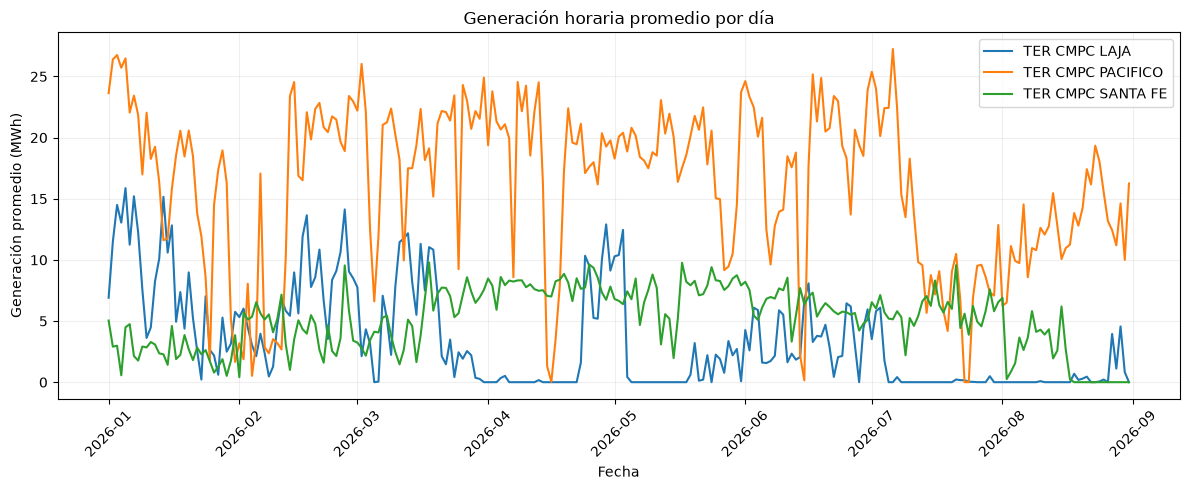

In [21]:
generacion_diaria = (
    df_final.groupby(["Fecha", "Central"], as_index=False)["Generacion_MWh"].mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
for central, grupo in generacion_diaria.groupby("Central"):
    ax.plot(grupo["Fecha"], grupo["Generacion_MWh"], label=central)

ax.set_title("Generación horaria promedio por día")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación promedio (MWh)")
ax.legend()
ax.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 19. Visualización: perfil horario promedio

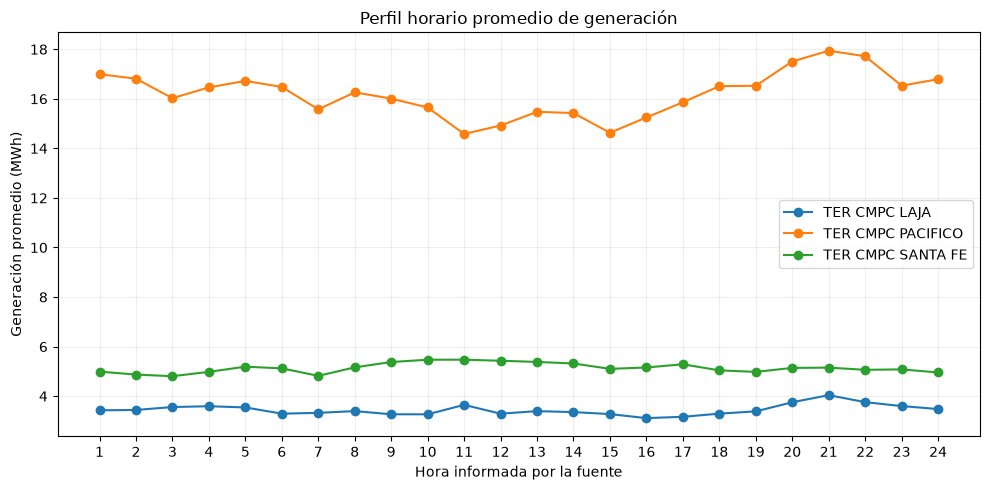

In [22]:
perfil_horario = (
    df_final.groupby(["Hora", "Central"], as_index=False)["Generacion_MWh"].mean()
)

fig, ax = plt.subplots(figsize=(10, 5))
for central, grupo in perfil_horario.groupby("Central"):
    ax.plot(grupo["Hora"], grupo["Generacion_MWh"], marker="o", label=central)

ax.set_title("Perfil horario promedio de generación")
ax.set_xlabel("Hora informada por la fuente")
ax.set_ylabel("Generación promedio (MWh)")
ax.set_xticks(range(1, 25))
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 20. Visualización: porcentaje de registros de 0 MWh por central

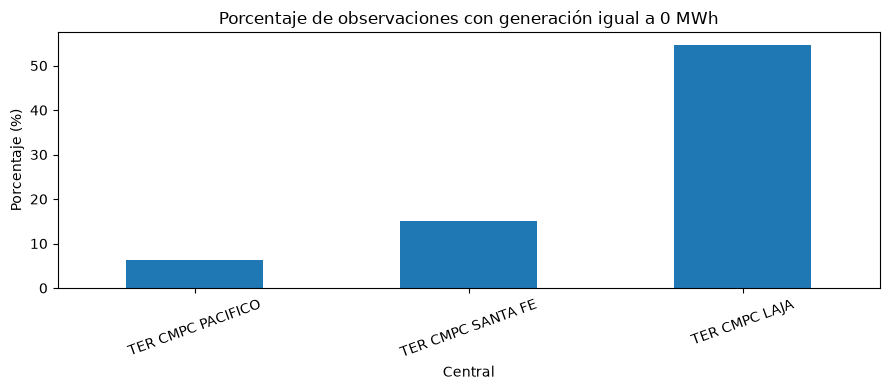

In [23]:
grafico_ceros = ceros_central["Porcentaje_Ceros"].sort_values()

fig, ax = plt.subplots(figsize=(9, 4))

grafico_ceros.plot(kind="bar", ax=ax)

ax.set_title("Porcentaje de observaciones con generación igual a 0 MWh")
ax.set_xlabel("Central")
ax.set_ylabel("Porcentaje (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [24]:
print("Dimensiones de df_final:", df_final.shape)
print("Columnas de df_final:")
print(df_final.columns.tolist())

Dimensiones de df_final: (17496, 13)
Columnas de df_final:
['ID_Observacion', 'Año', 'Mes', 'Llave', 'Central', 'Coordinado', 'Grupo_Reporte', 'Tipo', 'Subtipo', 'Fecha', 'Dia_Semana', 'Hora', 'Generacion_MWh']


## 21. Pruebas técnicas

Se consideran tres escenarios:

- **Caso normal:** el dataset construido satisface todas las validaciones.
- **Caso límite:** se introduce artificialmente un duplicado para comprobar que el control lo detecta.
- **Caso de excepción:** se verifica el comportamiento ante una ruta de archivo inexistente.

Los datos reales no se modifican durante estas pruebas.

In [25]:
# ============================================================
# PRUEBAS TÉCNICAS DEL PIPELINE
# ============================================================

# 1. CASO NORMAL
# El dataset correcto debe superar todas las validaciones.

resultados_validacion = validar_dataset_procesado(df_final)

print("Caso normal: OK")
print("Resumen de validación:")
print(resultados_validacion)


# 2. CASO LÍMITE: DUPLICADO ARTIFICIAL
# Creamos deliberadamente una copia de la primera observación
# para comprobar específicamente la detección de duplicados.

prueba_duplicado = pd.concat(
    [df_final, df_final.iloc[[0]]],
    ignore_index=True
)

try:
    validar_sin_duplicados_exactos(prueba_duplicado)

    raise AssertionError(
        "La validación no detectó el duplicado artificial."
    )

except AssertionError as error:
    print(
        "Caso límite: duplicado artificial "
        "detectado correctamente."
    )
    print("Detalle:", error)


# 3. CASO DE EXCEPCIÓN: ARCHIVO INEXISTENTE
# Se utiliza la función real de carga para comprobar
# el manejo controlado de un archivo que no existe.

ruta_inexistente = (
    RAIZ
    / "data"
    / "raw"
    / "archivo_que_no_existe.csv"
)

try:
    cargar_datos_cen(ruta_inexistente)

except FileNotFoundError as error:
    print("Caso de excepción controlado:", error)

Caso normal: OK
Resumen de validación:
{'filas': 17496, 'columnas': 13, 'nulos': 0, 'duplicados_exactos': 0, 'ids_duplicados': 0, 'negativos': 0, 'centrales': 3, 'fechas': 243}
Caso límite: duplicado artificial detectado correctamente.
Detalle: Se detectaron 1 registros exactamente duplicados.
Caso de excepción controlado: No se encontró el archivo fuente: C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\raw\archivo_que_no_existe.csv


## 22. Exportación del dataset procesado

La columna auxiliar `Es_Cero` se utiliza únicamente para la caracterización y no forma parte de las 13 variables finales.

In [26]:
df_exportar = df_final[columnas_finales].copy()

ruta_exportada = exportar_dataset(
    df_exportar,
    RUTA_PROCESADO
)

print("Dataset exportado en:")
print(ruta_exportada)
print("Dimensión exportada:", df_exportar.shape)


Dataset exportado en:
C:\Users\eliza\Desktop\ESTUDIOS\MAGÍSTER\1 PROGRAMACIÓN PARA LA CIENCIA\Proyecto\data\processed\dataset_cen_centrales_cmpc_ene_ago_2026.csv
Dimensión exportada: (17496, 13)


## 23. Validación posterior a la exportación

In [27]:
df_verificacion = pd.read_csv(
    RUTA_PROCESADO,
    encoding="utf-8-sig",
    parse_dates=["Fecha"]
)

resultado_relectura = validar_dataset_procesado(df_verificacion)

assert df_verificacion.shape == (17496, 13)
assert df_verificacion["ID_Observacion"].nunique() == 17496

print("Archivo procesado releído y validado correctamente.")
display(pd.DataFrame([resultado_relectura]))

Archivo procesado releído y validado correctamente.


,filas,columnas,nulos,duplicados_exactos,ids_duplicados,negativos,centrales,fechas
0,17496,13,0,0,0,0,3,243


## 24. Conclusión de F2

La fuente original contiene **359.891 registros × 33 variables**. El período de estudio se definió explícitamente entre el **1 de enero y el 31 de agosto de 2026** y el alcance comparativo se delimitó a tres centrales que comparten `Coordinado`, `Tipo`, `Subtipo` y cobertura temporal comparable. La selección conserva **729 filas en formato ancho**, equivalentes aproximadamente al **0,2026%** de las filas de la fuente, y no pretende representar al conjunto del Sistema Eléctrico Nacional.

La transformación ancho–largo convierte esos 729 registros central–fecha en **17.496 observaciones central–fecha–hora × 13 variables**. El resultado se valida mediante controles separados de dimensiones, nulos, duplicados, unicidad de identificadores, valores negativos, cantidad de centrales y granularidad de 24 observaciones por central–fecha.

Los **4.438 registros de 0 MWh (25,37%)** se conservan como valores válidos reportados por la fuente y se caracterizan descriptivamente por central, hora, hora por central, día de la semana por central y mes por central. Esta caracterización permite estudiar su distribución temporal sin atribuir causas operacionales que los datos no demuestran.

La carga, delimitación temporal, selección de centrales, transformación ancho–largo, creación de variables derivadas, validaciones y exportación se apoyan en funciones reutilizables de `src/`. El notebook también registra el entorno de Python y el estado de Git utilizado en la ejecución para fortalecer la trazabilidad y reproducibilidad del proceso.
